# Phase 3 (fallback) - DeepBrainNet zero-shot validation

In [ ]:
!pip -q install -U "tf-keras==2.20.1" "h5py>=3.11,<4"

In [ ]:
import os
from pathlib import Path

os.environ["TF_USE_LEGACY_KERAS"] = "1"

from google.colab import drive
drive.mount("/content/drive")

import tensorflow as tf
import tf_keras

print("TensorFlow:", tf.__version__)
print("tf_keras:", tf_keras.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", bool(gpus))
if gpus:
    print("Device:", gpus[0])
else:
    print("WARNING: no GPU detected. Inference can still run, but will be slower.")


Mounted at /content/drive
TensorFlow: 2.20.0
tf_keras: 2.20.1
GPU available: True
Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
import pandas as pd

PROJECT_DIR = Path("/content/drive/MyDrive/ML_Project")
PREPROCESSED_DIR = PROJECT_DIR / "IXI_preprocessed"
TEST_CSV = PROJECT_DIR / "ixi_test.csv"

for required in [PROJECT_DIR, PREPROCESSED_DIR, TEST_CSV]:
    if not required.exists():
        raise FileNotFoundError(f"Required path not found: {required}")

test_df = pd.read_csv(TEST_CSV)

required_columns = {"IXI_ID", "AGE"}
missing = required_columns - set(test_df.columns)
if missing:
    raise ValueError(f"ixi_test.csv is missing required columns: {sorted(missing)}")

print(f"Project: {PROJECT_DIR}")
print(f"Preprocessed scans: {PREPROCESSED_DIR}")
print(f"Test subjects: {len(test_df)}")
print(test_df.head())


Project: /content/drive/MyDrive/ML_Project
Preprocessed scans: /content/drive/MyDrive/ML_Project/IXI_preprocessed
Test subjects: 75
   IXI_ID  site                 filename  \
0     445    HH    IXI445-HH-2269-T1.nii   
1     387    HH    IXI387-HH-2101-T1.nii   
2     422  Guys  IXI422-Guys-1071-T1.nii   
3      35   IOP   IXI035-IOP-0873-T1.nii   
4     254    HH    IXI254-HH-1705-T1.nii   

                                           file_path  SEX        AGE  \
0  G:\My Drive\ML_Project\IXI_data\IXI445-HH-2269...    1  72.306639   
1  G:\My Drive\ML_Project\IXI_data\IXI387-HH-2101...    1  28.347707   
2  G:\My Drive\ML_Project\IXI_data\IXI422-Guys-10...    2  34.012320   
3  G:\My Drive\ML_Project\IXI_data\IXI035-IOP-087...    1  31.854894   
4  G:\My Drive\ML_Project\IXI_data\IXI254-HH-1705...    2  45.752224   

  sex_label                                  preprocessed_path  
0      Male  G:\My Drive\ML_Project\IXI_preprocessed\IXI445...  
1      Male  G:\My Drive\ML_Project\IXI_

In [ ]:
!apt-get update -qq
!apt-get install -y -qq git-lfs
!git lfs install --skip-repo


W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package git-lfs.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.4.1-1ubuntu0.4_amd64.deb ...
Unpacking git-lfs (3.4.1-1ubuntu0.4) ...
Setting up git-lfs (3.4.1-1ubuntu0.4) ...
Processing triggers for man-db (2.12.0-4build2) ...
Git LFS initialized.


In [ ]:
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/DeepBrainNet")
WEIGHTS_PATH = REPO_DIR / "Models" / "DBN_model.h5"

if not REPO_DIR.exists():
    !git clone --depth 1 https://github.com/vishnubashyam/DeepBrainNet.git /content/DeepBrainNet

!cd /content/DeepBrainNet && git lfs pull

if not WEIGHTS_PATH.exists():
    raise FileNotFoundError(f"DeepBrainNet weights not found: {WEIGHTS_PATH}")

weights_size_mb = WEIGHTS_PATH.stat().st_size / 1e6
print(f"DeepBrainNet weights: {WEIGHTS_PATH}")
print(f"Size: {weights_size_mb:.2f} MB")

if weights_size_mb < 100:
    raise RuntimeError(
        "DBN_model.h5 is unexpectedly small. The Git LFS object was not retrieved."
    )


Cloning into '/content/DeepBrainNet'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 16 (delta 0), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 10.36 MiB | 15.02 MiB/s, done.
DeepBrainNet weights: /content/DeepBrainNet/Models/DBN_model.h5
Size: 182.98 MB


In [ ]:
from tf_keras.models import load_model

print("Loading DeepBrainNet with tf_keras...")
model = load_model(str(WEIGHTS_PATH), compile=False)
print("Model loaded successfully.")
model.summary()


Loading DeepBrainNet with tf_keras...
Model loaded successfully.
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d_2  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_3 (Dense)             (None, 1024)              525312    
                                                                 
 dropout_2 (Dropout)         (None, 1024)              0         
                                                                 
 dense_4 (Dense)             (None, 1)                 1025      
                                                                 
Total params: 15241025 (58.14 MB)
Trainable params: 152

## 6. Verify the model input/output

In [ ]:
print("Input:", model.input_shape)
print("Output:", model.output_shape)

if len(model.input_shape) != 4:
    raise ValueError(f"Unexpected model input shape: {model.input_shape}")

if model.input_shape[-1] != 3:
    raise ValueError(f"Expected 3-channel RGB input, got: {model.input_shape}")

print("Model interface looks compatible with the slice-based validation.")


Input: (None, None, None, 3)
Output: (None, 1)
Model interface looks compatible with the slice-based validation.


## 7. Select the same held-out test subset

In [8]:
N_SAMPLES = min(8, len(test_df))
sample_df = test_df.sample(N_SAMPLES, random_state=42).reset_index(drop=True)

print(f"Testing {N_SAMPLES} held-out IXI subjects:")
for _, row in sample_df.iterrows():
    print(
        f"  IXI{int(row['IXI_ID']):03d} | "
        f"site={row.get('site', 'NA')} | "
        f"sex={row.get('sex_label', 'NA')} | "
        f"age={float(row['AGE']):.1f}"
    )


Testing 8 held-out IXI subjects:
  IXI254 | site=HH | sex=Female | age=45.8
  IXI222 | site=Guys | sex=Female | age=24.0
  IXI063 | site=Guys | sex=Female | age=36.5
  IXI445 | site=HH | sex=Male | age=72.3
  IXI385 | site=HH | sex=Female | age=67.2
  IXI298 | site=Guys | sex=Male | age=67.8
  IXI181 | site=Guys | sex=Female | age=40.4
  IXI276 | site=HH | sex=Male | age=65.9


## 8. Convert each preprocessed volume to DeepBrainNet slices

The official DeepBrainNet scripts expect T1 scans that are skull-stripped and linearly registered. The original slicer rescales by the 97th percentile, converts axial slices to RGB, and uses 80 slices. citeturn1view0turn1view2

Our Phase 2 `.npy` volumes are already percentile-normalized to approximately `[0, 1]`. We therefore preserve the original notebook's adaptation: apply the DeepBrainNet 97th-percentile rescale, then convert to RGB and `/255`.

The original script uses axial indices 45 through 124. Because our Phase 2 volumes are `160 x 192 x 160`, this notebook keeps the original 80-slice count but uses the centered 80 axial slices so the selection is explicit and shape-safe.

In [ ]:
import numpy as np

N_SLICES = 80
BATCH_SIZE = 80

def volume_to_slices(npy_path):
    volume = np.load(npy_path).astype(np.float32)

    if volume.ndim != 3:
        raise ValueError(
            f"{npy_path.name}: expected 3-D volume, got {volume.shape}"
        )
    z_start = 45
    z_end = 125

    if volume.shape[-1] < z_end:
        raise ValueError(
            f"{npy_path.name}: z dimension {volume.shape[-1]} "
            f"is too small for slices {z_start}:{z_end}"
        )

    p97 = float(np.percentile(volume, 97))

    if not np.isfinite(p97) or p97 <= 0:
        raise ValueError(
            f"{npy_path.name}: invalid 97th percentile: {p97}"
        )

    rescaled = volume * (185.0 / p97)

    slices = []

    for z in range(z_start, z_end):
        sl = rescaled[:, :, z]
        rgb = np.stack([sl, sl, sl], axis=-1)
        slices.append(rgb)

    batch = np.stack(slices, axis=0).astype(np.float32)

    batch /= 255.0

    return batch


def predict_age(npy_path):
    batch = volume_to_slices(npy_path)

    slice_preds = model.predict(
        batch,
        batch_size=BATCH_SIZE,
        verbose=0
    ).reshape(-1)

    if len(slice_preds) != N_SLICES:
        raise ValueError(
            f"Expected {N_SLICES} slice predictions, got {len(slice_preds)}"
        )

    return float(np.median(slice_preds)), slice_preds

## 9. Run zero-shot inference

In [15]:
results = []
all_slice_ranges = []

for _, row in sample_df.iterrows():
    ixi_id = int(row["IXI_ID"])
    npy_path = PREPROCESSED_DIR / f"IXI{ixi_id:03d}.npy"

    if not npy_path.exists():
        raise FileNotFoundError(f"Missing preprocessed scan: {npy_path}")

    predicted_age, slice_preds = predict_age(npy_path)

    results.append({
        "IXI_ID": ixi_id,
        "site": row.get("site", np.nan),
        "sex": row.get("sex_label", np.nan),
        "actual_age": float(row["AGE"]),
        "predicted_age": predicted_age,
        "slice_pred_min": float(np.min(slice_preds)),
        "slice_pred_max": float(np.max(slice_preds)),
        "slice_pred_std": float(np.std(slice_preds)),
    })

    print(
        f"IXI{ixi_id:03d}: "
        f"actual={float(row['AGE']):.1f}, "
        f"predicted={predicted_age:.1f}, "
        f"slice range={np.min(slice_preds):.1f}-{np.max(slice_preds):.1f}"
    )

results_df = pd.DataFrame(results)


IXI254: actual=45.8, predicted=49.3, slice range=36.9-76.4
IXI222: actual=24.0, predicted=57.9, slice range=45.2-75.4
IXI063: actual=36.5, predicted=65.2, slice range=51.8-76.8
IXI445: actual=72.3, predicted=65.3, slice range=51.8-76.5
IXI385: actual=67.2, predicted=68.1, slice range=57.4-80.3
IXI298: actual=67.8, predicted=63.8, slice range=49.4-74.6
IXI181: actual=40.4, predicted=66.3, slice range=55.5-80.2
IXI276: actual=65.9, predicted=61.5, slice range=51.4-76.3


## 10. Calculate MAE and inspect predictions

In [16]:
results_df["abs_error"] = (
    results_df["predicted_age"] - results_df["actual_age"]
).abs()

mae = float(results_df["abs_error"].mean())

print(f"Zero-shot MAE: {mae:.2f} years (n={len(results_df)})")
display(results_df)

print("\nPrediction sanity range:")
print(f"Actual age:    {results_df['actual_age'].min():.1f} - {results_df['actual_age'].max():.1f}")
print(f"Predicted age: {results_df['predicted_age'].min():.1f} - {results_df['predicted_age'].max():.1f}")


Zero-shot MAE: 13.53 years (n=8)


,IXI_ID,site,sex,actual_age,predicted_age,slice_pred_min,slice_pred_max,slice_pred_std,abs_error
0,254,HH,Female,45.752224,49.325821,36.891415,76.396103,10.177270,3.573596
1,222,Guys,Female,24.002738,57.937317,45.186115,75.379280,8.302862,33.934579
2,63,Guys,Female,36.479124,65.163025,51.830013,76.756424,6.049327,28.683901
3,445,HH,Male,72.306639,65.330673,51.845139,76.511444,5.340560,6.975966
4,385,HH,Female,67.241615,68.064575,57.432697,80.278961,5.285933,0.822960
5,298,Guys,Male,67.772758,63.778854,49.380379,74.574799,6.142911,3.993904
6,181,Guys,Female,40.361396,66.281723,55.485943,80.180092,5.538503,25.920327
7,276,HH,Male,65.853525,61.481987,51.388699,76.279160,6.723716,4.371538



Prediction sanity range:
Actual age:    24.0 - 72.3
Predicted age: 49.3 - 68.1


## 11. Save the zero-shot scatter plot

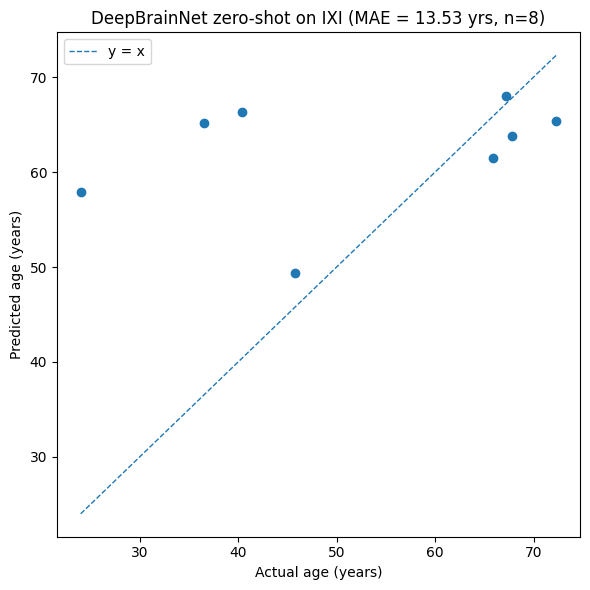

Saved: /content/drive/MyDrive/ML_Project/phase3_deepbrainnet_zeroshot_scatter.png


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    results_df["actual_age"],
    results_df["predicted_age"]
)

lo = min(results_df["actual_age"].min(), results_df["predicted_age"].min())
hi = max(results_df["actual_age"].max(), results_df["predicted_age"].max())

ax.plot(
    [lo, hi],
    [lo, hi],
    linestyle="--",
    linewidth=1,
    label="y = x"
)

ax.set_xlabel("Actual age (years)")
ax.set_ylabel("Predicted age (years)")
ax.set_title(
    f"DeepBrainNet zero-shot on IXI "
    f"(MAE = {mae:.2f} yrs, n={len(results_df)})"
)
ax.legend()
plt.tight_layout()

plot_path = PROJECT_DIR / "phase3_deepbrainnet_zeroshot_scatter.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {plot_path}")


## 12. Save results and print the decision information

In [13]:
results_path = PROJECT_DIR / "phase3_deepbrainnet_zeroshot_results.csv"
results_df.to_csv(results_path, index=False)

print("Decision rule (implementation.md, Section 3, applied to the fallback):")
print("  Plausible predictions, roughly tracking real age -> proceed with DeepBrainNet (Phase 4)")
print("  Still fails to load / crashes / nonsensical predictions -> re-examine preprocessing")
print()
print(f"Observed zero-shot MAE: {mae:.2f} years (n={len(results_df)})")
print(f"Results saved to: {results_path}")
print()
print("IMPORTANT: MAE alone is not the entire sanity check. Inspect the prediction table and scatter plot,")
print("especially because this validation uses only 8 held-out subjects.")


Decision rule (implementation.md, Section 3, applied to the fallback):
  Plausible predictions, roughly tracking real age -> proceed with DeepBrainNet (Phase 4)
  Still fails to load / crashes / nonsensical predictions -> re-examine preprocessing

Observed zero-shot MAE: 13.45 years (n=8)
Results saved to: /content/drive/MyDrive/ML_Project/phase3_deepbrainnet_zeroshot_results.csv

IMPORTANT: MAE alone is not the entire sanity check. Inspect the prediction table and scatter plot,
especially because this validation uses only 8 held-out subjects.
